# Lab02 - Warps and Divergence

## Ex. 1) Parallel Reduction

Sum of values in an array

In [1]:
import numpy as np
import time
import numba
from numba import cuda

print(np.__version__)
print(numba.__version__)

cuda.detect()

2.3.5
0.63.1
Found 1 CUDA devices
id 0    b'NVIDIA GeForce RTX 2060'                              [SUPPORTED]
                      Compute Capability: 7.5
                           PCI Device ID: 0
                              PCI Bus ID: 1
                                    UUID: GPU-006291b6-94bd-bac8-588d-4a97f26284e1
                                Watchdog: Enabled
                            Compute Mode: WDDM
             FP32/FP64 Performance Ratio: 32
Summary:
	1/1 devices are supported


True

In [ ]:
# RACE CONDITION VERSION:

SIZE = 1024 * 1024
a_host = np.random.randint(0, 100, SIZE)
#a_host = np.ones(SIZE)

BLOCK_SIZE = 512
GRID_SIZE = (SIZE + BLOCK_SIZE - 1) // BLOCK_SIZE

print(f"{GRID_SIZE} Blocks of {BLOCK_SIZE} Threads each")

out_host = np.zeros(GRID_SIZE)

a_device = cuda.to_device(a_host)
out_device = cuda.device_array_like(out_host)

@cuda.jit
def reduce(arr, out):
    global_idx = cuda.grid(1)
    block_idx = cuda.blockIdx.x
    thread_idx = cuda.threadIdx.x
    first_thread_in_block_idx = block_idx * cuda.blockDim.x
    
    if global_idx >= len(arr):
        return
    
    stride = 2
    while stride <= cuda.blockDim.x:
        if thread_idx < cuda.blockDim.x / stride:
            first = first_thread_in_block_idx + (thread_idx * 2)
            second = first_thread_in_block_idx + (thread_idx * 2) + 1 
            arr[global_idx] = arr[first] + arr[second] # TERRIBLE MISTAKE!!!
        cuda.syncthreads() # Make sure all threads within the block have done their job
        stride *= 2

    # In the end, write the total inside out
    if global_idx == first_thread_in_block_idx:
        out[block_idx] = arr[first_thread_in_block_idx]
    
reduce[GRID_SIZE, BLOCK_SIZE](a_device, out_device)
cuda.synchronize()

out_host = out_device.copy_to_host()

print(f"Got: {sum(out_host)}")
print(f"Expected: {sum(a_host)}")
assert sum(out_host) == sum(a_host)

In [10]:
SIZE = 1024 * 1024
a_host = np.random.randint(0, 100, SIZE)
#a_host = np.ones(SIZE)

BLOCK_SIZE = 1024
GRID_SIZE = (SIZE + BLOCK_SIZE - 1) // BLOCK_SIZE

print(f"{GRID_SIZE} Blocks of {BLOCK_SIZE} Threads each")

out_host = np.zeros(GRID_SIZE)

a_device = cuda.to_device(a_host)
out_device = cuda.device_array_like(out_host)

@cuda.jit
def reduce(arr, out):
    global_idx = cuda.grid(1)
    block_idx = cuda.blockIdx.x
    thread_idx = cuda.threadIdx.x
    first_thread_in_block_idx = block_idx * cuda.blockDim.x
    
    if global_idx >= len(arr):
        return
    
    stride = 1
    while stride < cuda.blockDim.x:
        if thread_idx < cuda.blockDim.x / (stride * 2): # Each time, half the threads stop working
            relative_idx = thread_idx * stride * 2
            arr[first_thread_in_block_idx + relative_idx] += arr[first_thread_in_block_idx + relative_idx + stride] 
        cuda.syncthreads() # Make sure all threads within the block have done their job
        stride *= 2

    # In the end, write the total inside out
    if global_idx == first_thread_in_block_idx:
        out[block_idx] = arr[first_thread_in_block_idx]
    
reduce[GRID_SIZE, BLOCK_SIZE](a_device, out_device)
cuda.synchronize()

out_host = out_device.copy_to_host()

print(f"Got: {sum(out_host)}")
print(f"Expected: {sum(a_host)}")
assert sum(out_host) == sum(a_host)

1024 Blocks of 1024 Threads each
Got: 51932986.0
Expected: 51932986


## Ex.2) Image Histogram

**Problem Description**

-   Given an RGB image `image` of shape: $(H, W, 3)$

-   compute a histogram such that:

    -   `histogram[0, i]` = num pixels with **red value** `i`
    -   `histogram[1, i]` = num pixels with **green value** `i`
    -   `histogram[2, i]` = num pixels with **blue value** `i`

-   Each color channel has **256 bins**

Image size: 1024 x 524 x 3


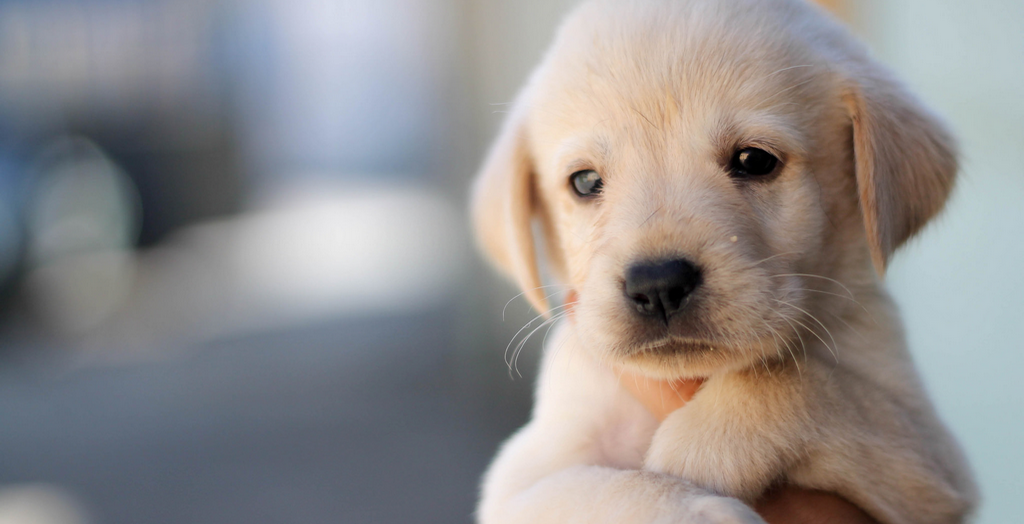

In [3]:
import requests
import numpy as np
from PIL import Image
from io import BytesIO

url = "https://raw.githubusercontent.com/Filippo-Corti/GPUComputing/refs/heads/main/data/dog.bmp"

response = requests.get(url)

raw_img = Image.open(BytesIO(response.content))

img_host = np.array(raw_img).astype(np.uint8)
H, W, C = img_host.shape
print(f"Image size: {W} x {H} x {C}")
raw_img

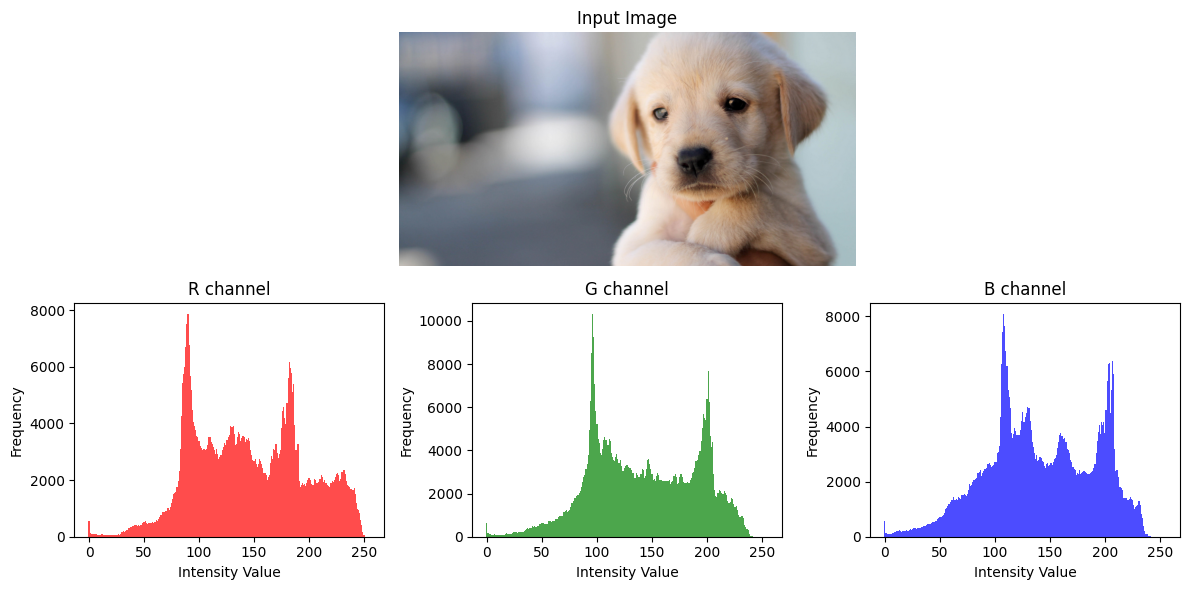

In [5]:
import matplotlib.pyplot as plt

histogram_host = np.zeros(shape=(3, 256), dtype=np.int32)

img_device = cuda.to_device(img_host)
histogram_device = cuda.device_array_like(histogram_host)

BLOCK_SIZE = (16, 16)
GRID_SIZE = ((W + BLOCK_SIZE[0] - 1) // BLOCK_SIZE[0], (H + BLOCK_SIZE[1] - 1) // BLOCK_SIZE[1])

@cuda.jit
def histogram(img, hist):
    col, row = cuda.grid(2)
    
    H, W, C = img.shape
    if col >= W or row >= H:
        return
    
    for i in range(C):
        #hist[i, img[row, col, i]] += 1 # This causes race condition!!
        cuda.atomic.add(hist, (i, img[row, col, i]), 1) # This, instead, is safe!
        
histogram[GRID_SIZE, BLOCK_SIZE](img_device, histogram_device)
cuda.synchronize()
    
histogram_host = histogram_device.copy_to_host()

# Plot
colors = ['r', 'g', 'b']
plt.figure(figsize=(12,6))
ax_img = plt.subplot2grid((2,3), (0,0), colspan=3)
ax_img.imshow(img_host)
ax_img.axis('off')
ax_img.set_title('Input Image')

for i in range(3):
    ax = plt.subplot2grid((2,3), (1, i))
    ax.bar(np.arange(256), histogram_host[i], color=colors[i], alpha=0.7, width=1)
    ax.set_title(f'{colors[i].upper()} channel')
    ax.set_xlabel('Intensity Value')
    ax.set_ylabel('Frequency')
 
plt.tight_layout()
plt.show()

## Ex. 3) Prefix-Scan

Given an array [a, b, c, d].
Return the array with the partial sums [a, a+b, a+b+c, a+b+c+d]


> Notice that the Naive Horn Algorithm (which is, either way, not Work Efficient) is not memory safe and requires two arrays to be implemented

In [76]:
def prefix_scan_cpu(a):
    b = np.zeros(a.shape)
    b[0] = 0
    for i in range(0, len(a) - 1):
        b[i + 1] = b[i] + a[i]
    return b

In [14]:
# Simple Method (memory unsafe)

SIZE = 64

#arr_host = np.random.randint(0, 100, SIZE)
arr_host = np.ones(SIZE)

arr_device = cuda.to_device(arr_host)

BLOCK_SIZE = 32
GRID_SIZE = (SIZE + BLOCK_SIZE - 1) // BLOCK_SIZE

@cuda.jit
def prefix_scan(arr):
    idx = cuda.grid(1)
    
    if idx >= len(arr):
        return
    
    stride = 1
    while stride < len(arr):
        if idx >= stride:
            arr[idx] += arr[idx - stride] 
        stride *= 2
        cuda.syncthreads()       
        
prefix_scan[GRID_SIZE, BLOCK_SIZE](arr_device)
cuda.synchronize()
    
arr_host = arr_device.copy_to_host()

print(arr_host)

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 30. 32. 35. 37.
 34. 36. 39. 41. 29. 30. 32. 33. 29. 30. 32. 33. 45. 46. 48. 49. 45. 46.
 48. 49. 36. 36. 37. 37. 32. 32. 33. 33.]


c:\Users\Filippo Corti\Documents\GitHub\GPUComputing\.venv\Lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 2 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


In [ ]:
# Blelloch's Prefix Scan

SIZE = 16 # Assumes power of two size

arr_host = np.random.randint(0, 100, SIZE)
#arr_host = np.ones(SIZE)
#arr_host = np.array([3, 1, 7, 0, 4, 1, 6, 3])

arr_device = cuda.to_device(arr_host)

BLOCK_SIZE = min(SIZE, 16) # Assume single block for now...
GRID_SIZE = (SIZE + BLOCK_SIZE - 1) // BLOCK_SIZE

print(f"{GRID_SIZE} Blocks of {BLOCK_SIZE} Threads each")
print(arr_host)

expected = prefix_scan_cpu(arr_host)

@cuda.jit
def prefix_scan(arr):
    global_idx = cuda.grid(1)
    thread_idx = cuda.threadIdx.x
    block_idx = cuda.blockIdx.x
    first_thread_in_block_idx = block_idx * cuda.blockDim.x
    
    if global_idx >= len(arr):
        return
    
    # Up-sweep
    stride = 2
    threads_needed = (cuda.blockDim.x * 2 - 1) // 2
    while stride <= cuda.blockDim.x:
        if thread_idx < threads_needed:
            target_idx = first_thread_in_block_idx + thread_idx * stride + (stride - 1)
            arr[target_idx] += arr[target_idx - (stride // 2)]
            
        stride *= 2
        threads_needed //= 2
        cuda.syncthreads()
        
    arr[first_thread_in_block_idx + cuda.blockDim.x - 1] = 0
    
    # Down-sweep
    stride = cuda.blockDim.x
    threads_needed = 1
    while stride > 1:
        if thread_idx < threads_needed:
            right_target_idx = first_thread_in_block_idx + thread_idx * stride + (stride - 1)
            left_target_idx = right_target_idx - (stride // 2)
            temp = arr[left_target_idx]
            arr[left_target_idx] = arr[right_target_idx]
            arr[right_target_idx] += temp
            
        stride //= 2
        threads_needed *= 2
        cuda.syncthreads()

        
prefix_scan[GRID_SIZE, BLOCK_SIZE](arr_device)
cuda.synchronize()
    
arr_host = arr_device.copy_to_host()

# Post-processing by Host requires some extra work...

print(arr_host)
print(expected)
assert all([a == b for a, b in zip(arr_host, expected)])

1 Blocks of 16 Threads each
[51 46 86 34 64 91 34 72 17 16  8 41 58 28 43 93]
[  0  51  97 183 217 281 372 406 478 495 511 519 560 618 646 689]
[  0.  51.  97. 183. 217. 281. 372. 406. 478. 495. 511. 519. 560. 618.
 646. 689.]


c:\Users\Filippo Corti\Documents\GitHub\GPUComputing\.venv\Lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
